# Línea de base

## ResNet18 para Espectrogramas

In [1]:
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

I0000 00:00:1780855656.183266   16079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780855656.214416   16079 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780855657.163039   16079 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780855657.163283   16079 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

SAMPLE_RATE = 16000
N_MELS = 64
N_FFT = int(400)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(WIN_LENGTH/2)

In [3]:
final_path = '00-baseline_resnet18/final'
checkpoints_path = '00-baseline_resnet18/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/00-baseline_resnet18')
batch_size = 1024
epochs = 5

In [4]:
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE,
        mode = "training")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=10)                        
trainer.fit(resume=True)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/73 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 1.0214, Accuracy: 0.7150, F1-score: 0.7008
  Val   - Pérdida: 0.6336, Accuracy: 0.8043, F1-score: 0.7927


Batches entrenamiento:   0%|          | 0/73 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.0455, Accuracy: 0.9858, F1-score: 0.9844
  Val   - Pérdida: 0.4533, Accuracy: 0.9014, F1-score: 0.8950


Batches entrenamiento:   0%|          | 0/73 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.0427, Accuracy: 0.9863, F1-score: 0.9848
  Val   - Pérdida: 0.4983, Accuracy: 0.8945, F1-score: 0.8872


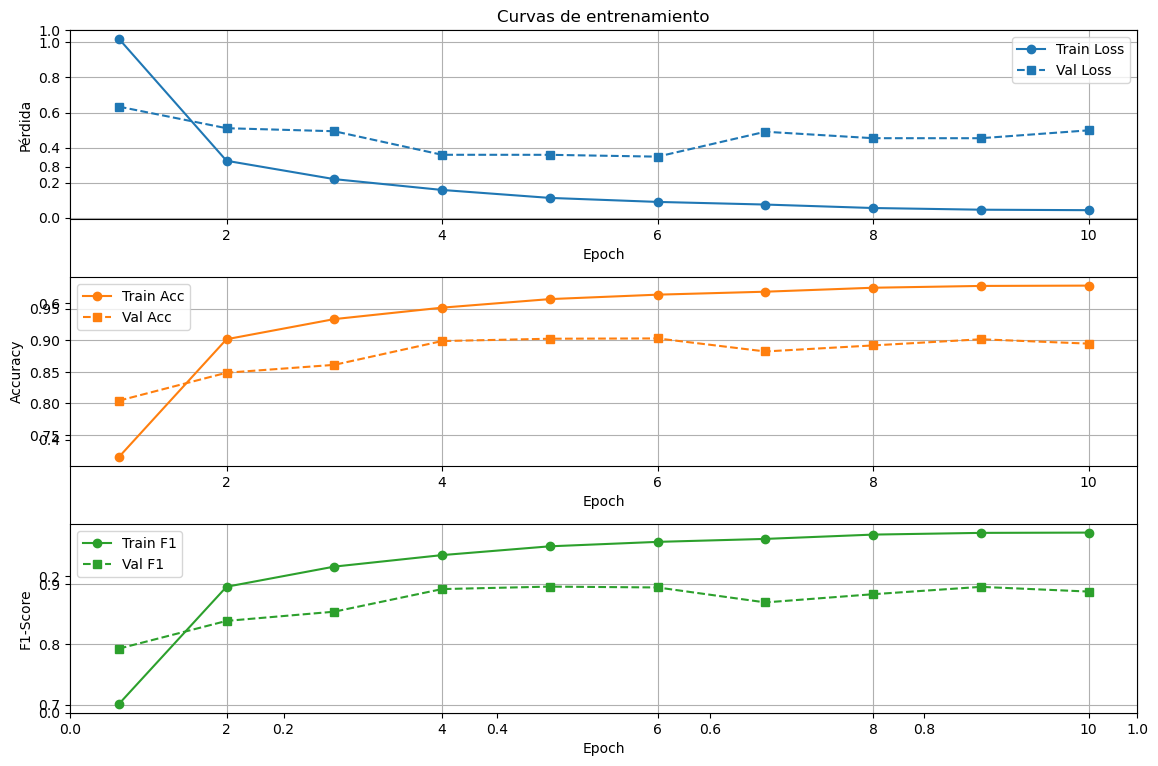

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

El modelo tiene unas métricas mejores de lo esperado en este primer entrenamiento, aunque se observa que la accuracy y la métrica de f1 en validación se encuentran con una cota en torno a 0.9, y que la función de pérdida aumenta a partir de la epoch 7, lo que parece indicar un sobreajuste del modelo a los datos de entrenamiento, cuyas métricas siguen mejorando. Se observa que el modelo escogido es particularmente interesante para el propósito de adaptación al usuario en _edge computing_, ya que es ligero de entrenar y consigue unas métricas muy adecuadas en seguida: a primera vista en las epochs 4 o 5 ya tenemos un modelo funcional. Vamos a cuantificar el desempeño del modelo a partir de la matriz de confusión del checkpoint en epoch 5, que tiene mejores métricas en validación que el modelo final:

In [7]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{checkpoints_path}/best_checkpoint_epoch_05.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/11 [00:00<?, ?it/s]

Pérdida: 0.6568501502911955 Accuracy: 0.8798903798903799 F1-Score: 0.8736021947700848


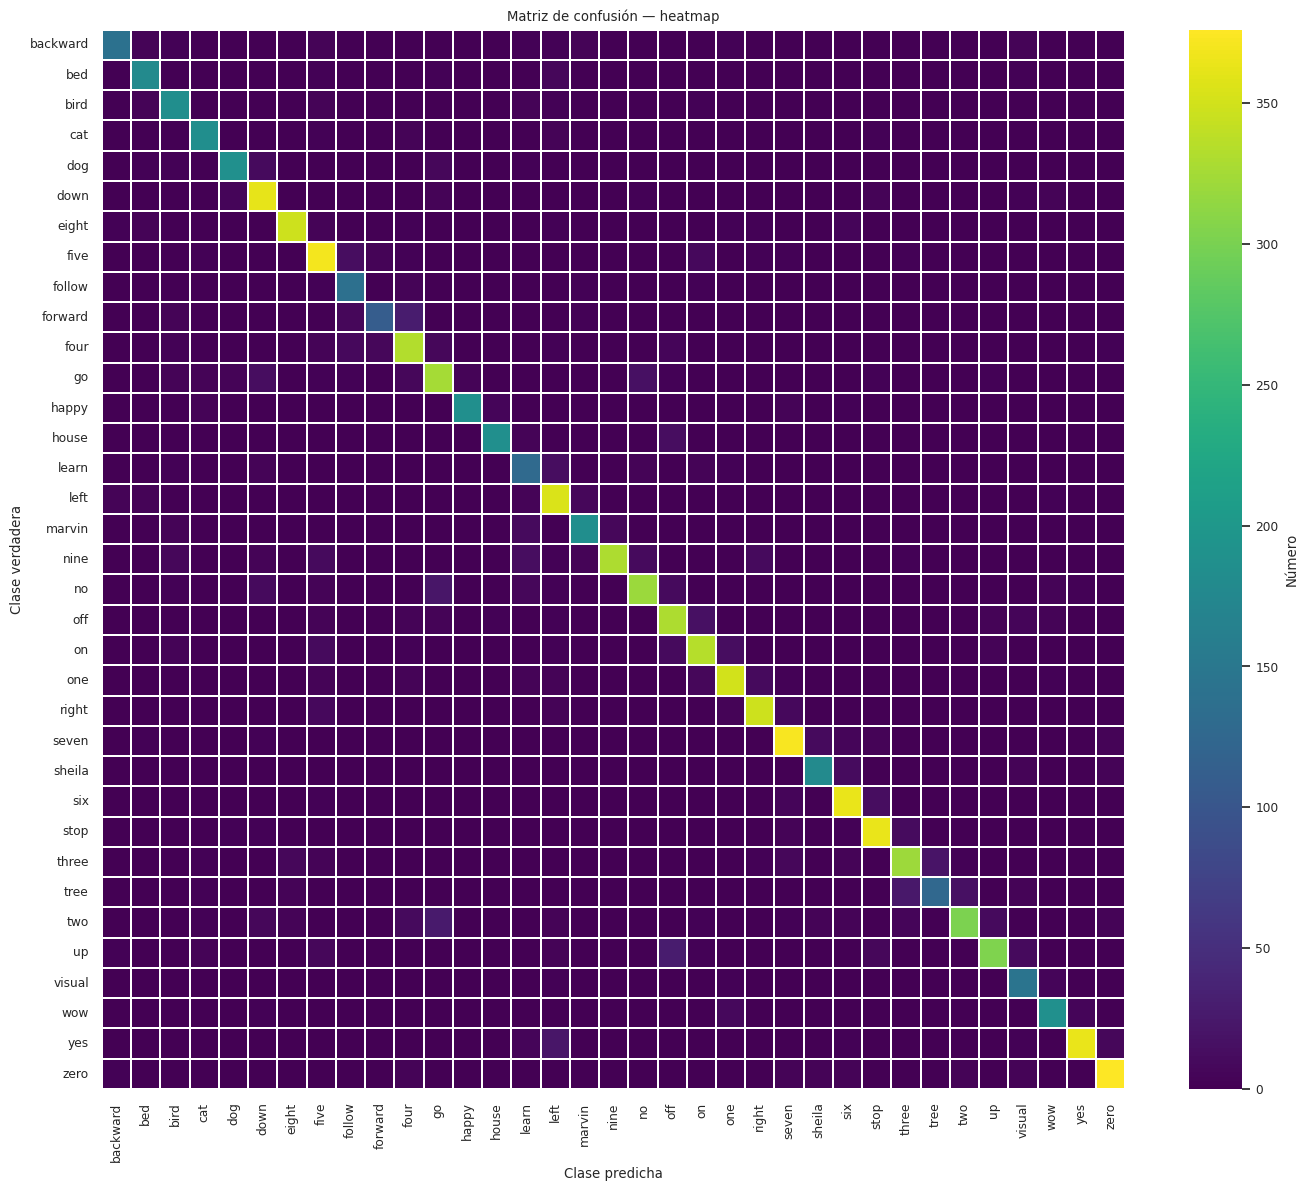

In [8]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

Observamos que las confusiones más importantes se dan entre los siguientes pares:

- no / go
- yes / left
- two / go
- off / up

Se observa que la similitud fonética entre ellos es evidente. Vamos a realizar una evaluación más profunda:

In [28]:
print(f"Accuracy: {accuracy:.4f}, Precision: {precission:.4f} Recall: {recall:.4f} Pérdida media: {avg_loss:.4f} F1-score: {f1:.4f}")

Accuracy: 0.8799, Precision: 0.8768 Recall: 0.8738 Pérdida media: 0.6569 F1-score: 0.8736


Observamos que las medidas de Precission y Recall están balanceadas, por lo que el número de falsos positivos y falsos negativos no es muy distante. Las medidas en general no están mal para un primer entrenamiento sin aumentaciones ni adaptaciones del modelo, pero son mejorables.

In [10]:
results = evaluator.eval_samples()
right = results[results['predicción'] == results['real']]
wrong = results[results['predicción'] != results['real']]

# Observaciones de la certeza del modelo
print("Número de errores:", wrong['path'].count(), "Porcentaje del total:", wrong['path'].count()*100/results['path'].count(), "%")

print("Aciertos: margen entre 2 opciones más probables - media:", right['margen'].mean())
print("Aciertos: margen entre 2 opciones más probables - primer cuartil:", right['margen'].quantile(0.25))

print("Errores: margen entre 2 opciones más probables - media:",  wrong['margen'].median())
print("Errores: margen entre 2 opciones más probables - tercer cuartil:", wrong['margen'].quantile(0.75))

Número de errores: 1271 Porcentaje del total: 12.010962010962011 %
Aciertos: margen entre 2 opciones más probables - media: 0.95305043
Aciertos: margen entre 2 opciones más probables - primer cuartil: 0.9935041964054108
Errores: margen entre 2 opciones más probables - media: 0.5642877
Errores: margen entre 2 opciones más probables - tercer cuartil: 0.9280206859111786


Obtenemos un número de errores de 1271, que suponen un 12% del total. La media de confianza del modelo es bastante menor en sus errores, lo que es un dato positivo, aunque en el tercer cuartil da unos valores de confianza muy altos en sus errores.

Vamos a profundizar en el estudio de estas cuestiones y comenzaremos por visualizar algunos de los espectrogramas que hemos preparado para el modelo, para hacernos una idea del punto de partida.

In [11]:
# Dataloaders para estudio
wrong_dataset = GSC(wrong['path'].tolist(), wrong['real'].tolist())
wrong_dataloader = DataLoader(wrong_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 6)

few_samples_dataset = GSC(wrong['path'].tolist()[:9], wrong['real'].tolist()[:9])
few_samples_dataloader = DataLoader(few_samples_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 6)

In [12]:
%%capture
# Nombres de archivo para persistencia
file_names = wrong['path'].apply(lambda p: Path(p).stem).tolist()

# Visualización de los espectrogramas de entrada
for batch_waves, _, _ in few_samples_dataloader:
    with torch.no_grad():
        mels = preprocessor_test.transform_batch(batch_waves)
        persister.save_spectrogram_images(specs = mels, file_names = file_names[:9])

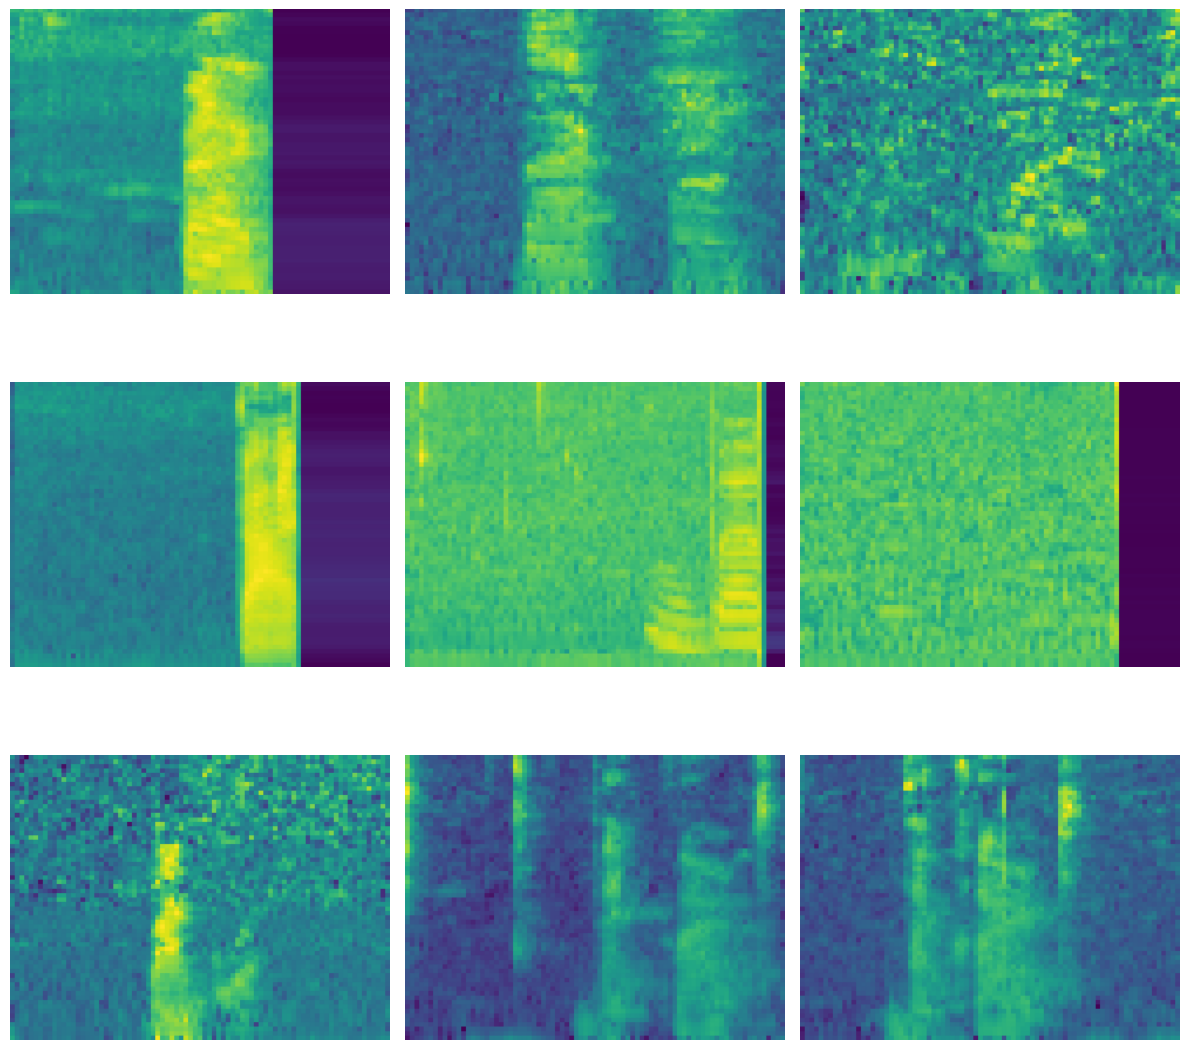

In [13]:
p = Path(f"{xai_path}/espectrogramas")
images_to_show = [i for i in p.iterdir()]
show_image_grid(images_to_show, rows=3, figsize=(12,12))

En principio se observa que la resolución frecuencial es bastante baja. Se aprecian los efectos de lo que podría ser el padding en algunos archivos. Vamos a identificar los errores más importantes del modelo para indagar algo en su comportamiento con signal_grad_cam.

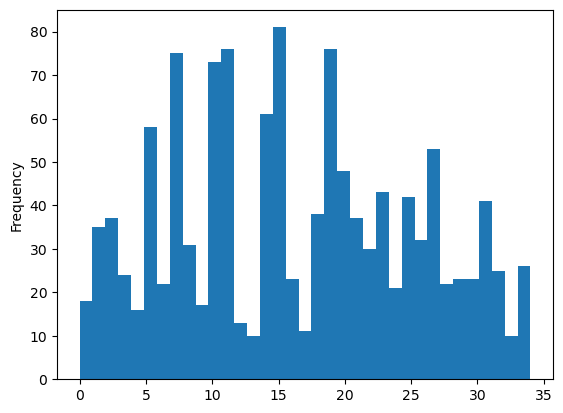

predicción
15    81
11    76
19    76
7     75
10    73
14    61
5     58
27    53
20    48
23    43
25    42
31    41
18    38
2     37
21    37
1     35
26    32
8     31
22    30
34    26
32    25
3     24
16    23
29    23
30    23
6     22
28    22
24    21
0     18
9     17
4     16
12    13
17    11
13    10
33    10
Name: count, dtype: int64


In [14]:
wrong['predicción'].plot.hist(bins=35)
plt.show()
print(wrong['predicción'].value_counts())

Aunque los errores están bastante distribuidos, vemos que en los falsos positivos el modelo ha errado bastante en las clases 7, 10, 11, 15 y 19, que vamos a estudiar más en profundidad:

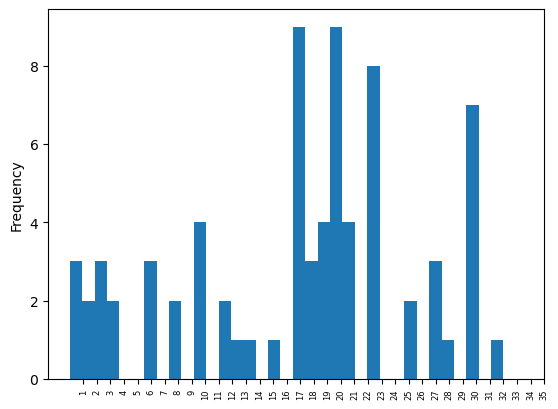

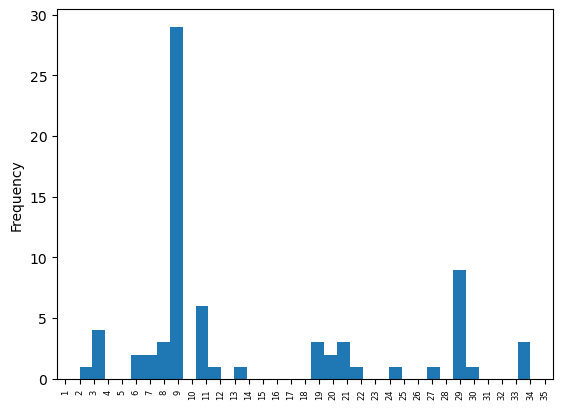

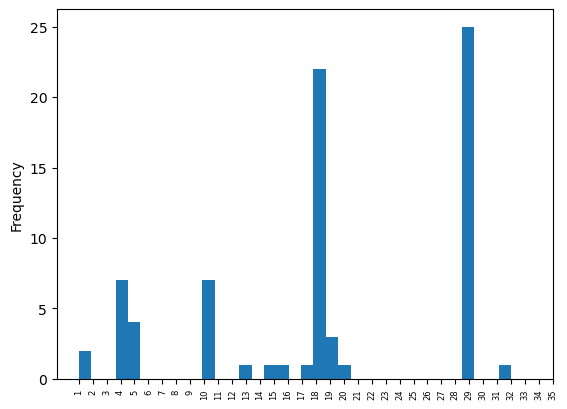

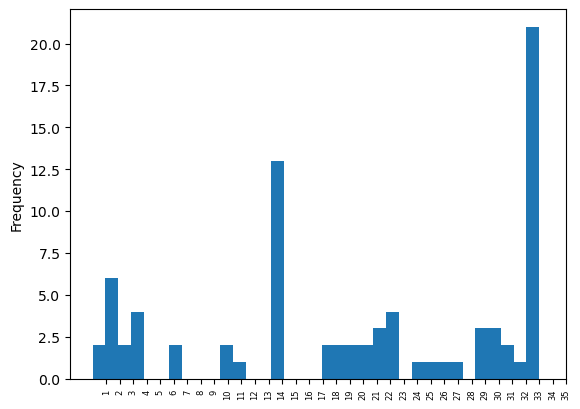

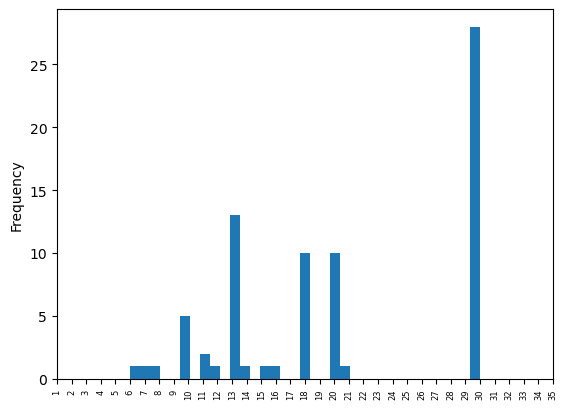

In [15]:
bins = np.arange(wrong['real'].min()+1, wrong['real'].max() + 2)
wrong[wrong['predicción'] == 7]['real'].plot.hist(bins=35)
plt.xticks(bins, rotation=90, fontsize=6)
plt.show()
wrong[wrong['predicción'] == 10]['real'].plot.hist(bins=35)
plt.xticks(bins, rotation=90, fontsize=6)
plt.show()
wrong[wrong['predicción'] == 11]['real'].plot.hist(bins=35)
plt.xticks(bins, rotation=90, fontsize=6)
plt.show()
wrong[wrong['predicción'] == 15]['real'].plot.hist(bins=35)
plt.xticks(bins, rotation=90, fontsize=6)
plt.show()
wrong[wrong['predicción'] == 19]['real'].plot.hist(bins=35)
plt.xticks(bins, rotation=90, fontsize=6)
plt.show()

In [16]:
print("Errores más comunes:")
print(label_names[7], "con", label_names[17], label_names[20], label_names[23], label_names[30])
print(label_names[10], "con", label_names[9])
print(label_names[11], "con", label_names[18], label_names[29])
print(label_names[15], "con", label_names[14], label_names[33])
print(label_names[19], "con", label_names[30])


Errores más comunes:
five con nine on seven up
four con forward
go con no two
left con learn yes
off con up


**XAI**

En primer lugar preparamos las listas para generar los cams de OFF vs UP. Los tenemos que duplica en las listas para ver los overlays de las dos explicaciones porque cuando se pasa una lista a signal_grad_cam la funciñon overlapped_output_display() renderiza todos los overlays uno encima del otro:

In [17]:
# CAMs clasificación errónea

## Preparamos los datos
off_up = wrong[wrong['predicción'] == 19]
off_up = off_up[off_up['real'] == 30]['path'].tolist()
off_up_datalist = []
off_up_labels = []
off_up_targets = []
for i, path in enumerate(off_up):
    off_up_datalist.extend([path, path])
    off_up_labels.extend([30,30])
    off_up_targets.extend([30,19])

off_up_dataset = GSC(off_up_datalist, off_up_labels)
off_up_loader = DataLoader(off_up_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 6)

In [18]:
%%capture

## Generamos los CAMs
target_layers = ['layer4.1.conv2']
explainer = "Grad-CAM"
signal_grad_cam_overlays2d(model=model, dataloader=off_up_loader, 
                           label_names=label_names, 
                           target_layers=target_layers, target_classes=[19, 30], 
                           targets_list=off_up_targets, 
                           preprocessor=preprocessor_test, 
                           xai_path=xai_path, explainer = explainer)

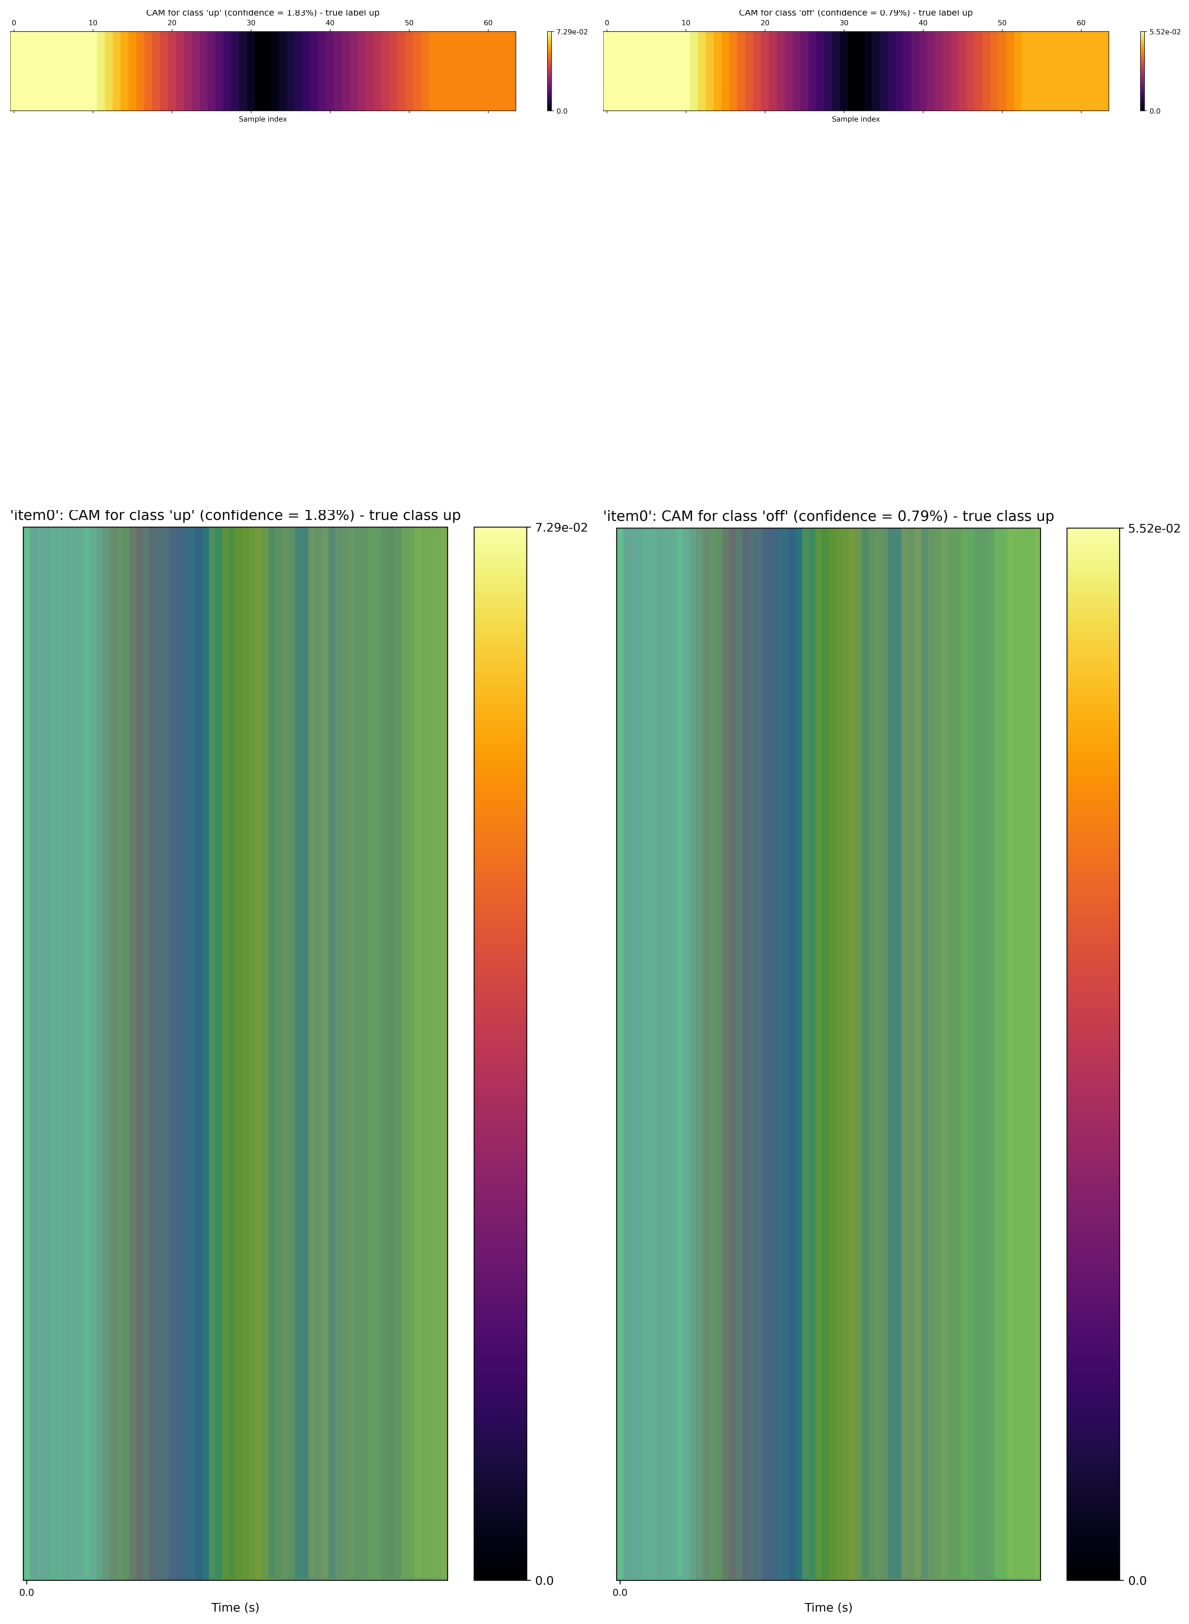

In [19]:
## Visualizamos para la primera muestra
images_to_show = []
images_to_show.extend([Path(f"{xai_path}/CAMs/0-55/item0/Grad-CAM_layer4_1_conv2_class30.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/0-55/item0/Grad-CAM_layer4_1_conv2_class19.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/overlays/0-55/item0/results_Grad-CAM_layer4_1_conv2_class30.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/overlays/0-55/item1/results_Grad-CAM_layer4_1_conv2_class19.png")])

show_image_grid(images_to_show, cols=2, figsize=(12,24))

Vamos a visualizar también los espectrogramas con HiResCAM para ver si nos puede dar más información.

In [18]:
%%capture

## Generamos los CAMs
target_layers = ['layer4.1.conv2']
explainer = "HiResCAM"
signal_grad_cam_overlays2d(model=model, dataloader=off_up_loader, label_names=label_names, target_layers=target_layers, target_classes=[19, 30], targets_list=off_up_targets, preprocessor=preprocessor_test, xai_path=xai_path, explainer = explainer)

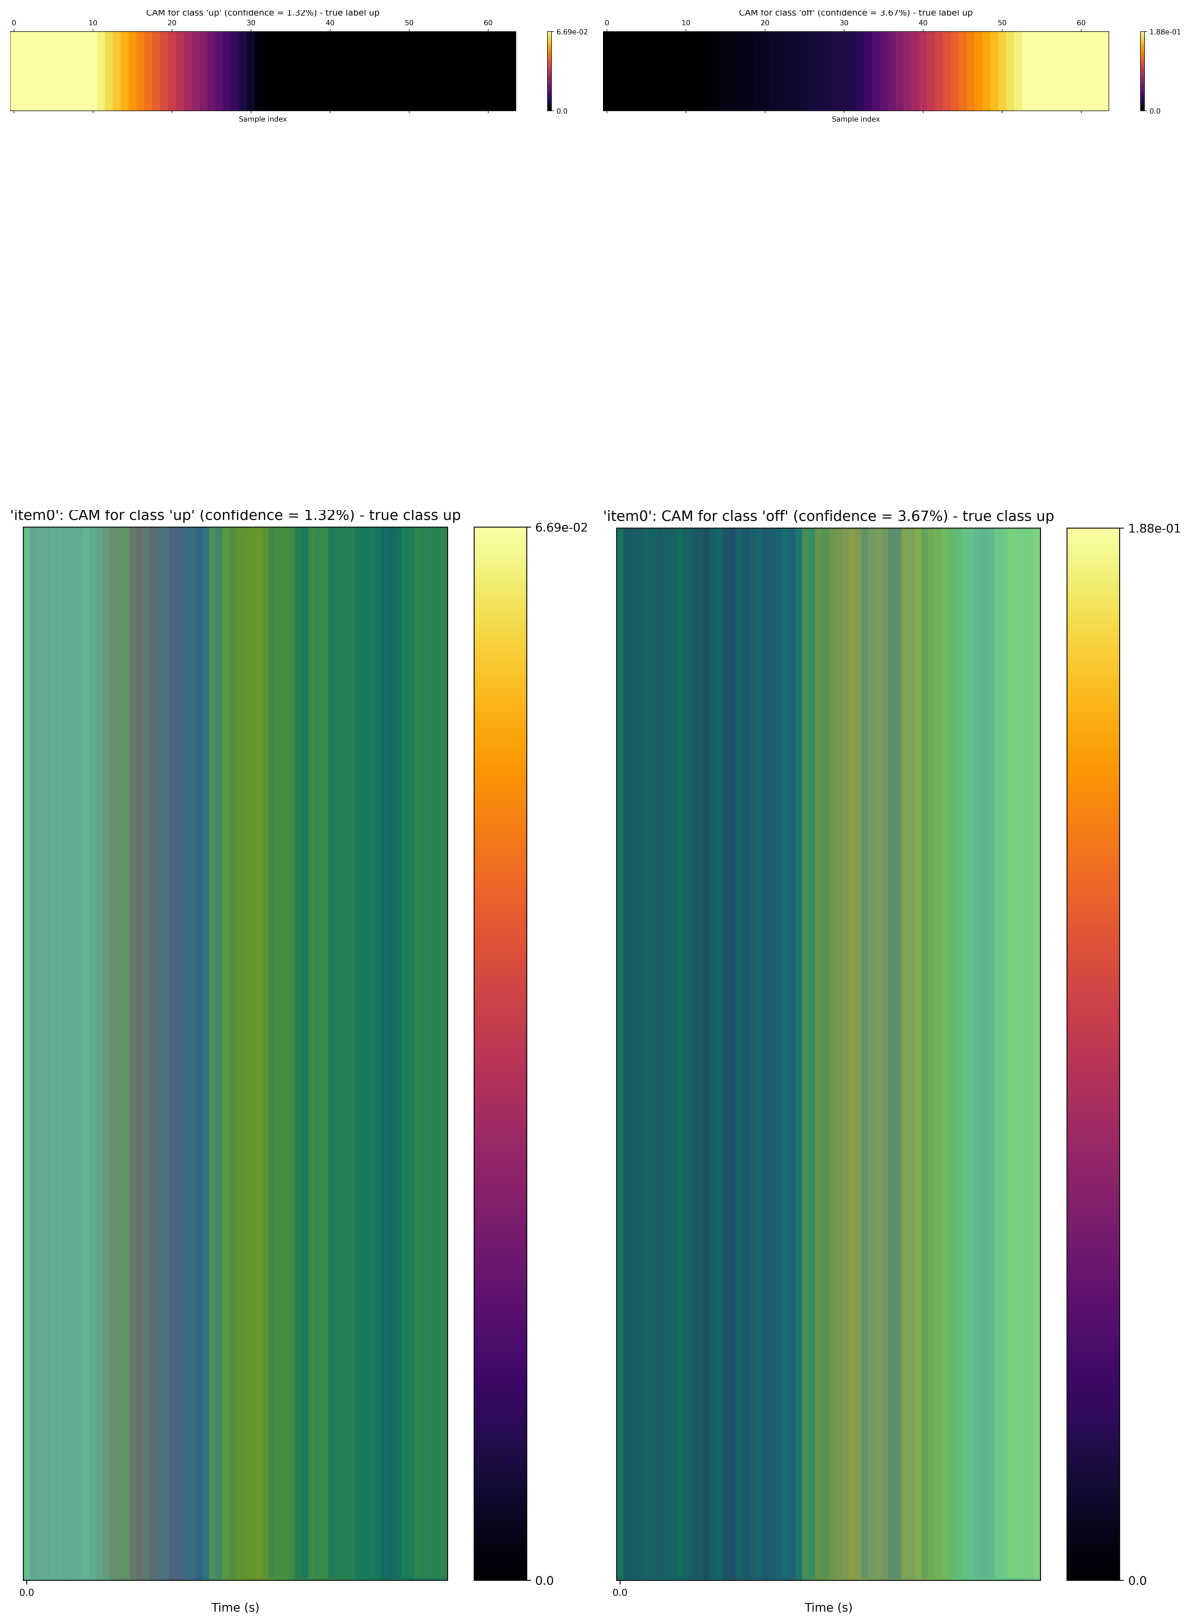

In [19]:
## Visualizamos para la primera muestra
images_to_show = []
images_to_show.extend([Path(f"{xai_path}/CAMs/0-55/item0/HiResCAM_layer4_1_conv2_class30.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/0-55/item0/HiResCAM_layer4_1_conv2_class19.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/overlays/0-55/item0/results_HiResCAM_layer4_1_conv2_class30.png")])
images_to_show.extend([Path(f"{xai_path}/CAMs/overlays/0-55/item1/results_HiResCAM_layer4_1_conv2_class19.png")])

show_image_grid(images_to_show, cols=2, figsize=(12,24))

Parece que en este caso existen diferencias algo significativas entre los dos algoritmos: HiResCAM parece algo más selectivo en los gradientes. Vamos a visualizarlo restando las CAMs de ambos algoritmos con respecto de la clase predicha.

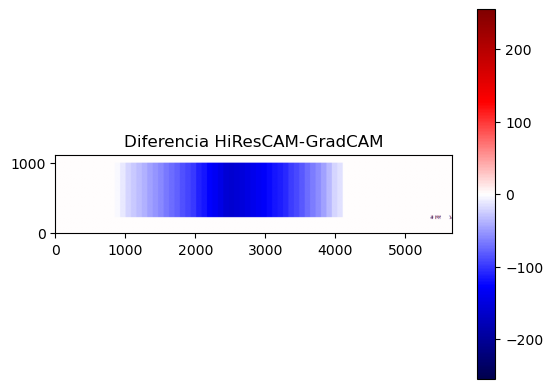

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

# CAM
cam_hr = np.array(Image.open(f"{xai_path}/CAMs/0-55/item0/HiResCAM_layer4_1_conv2_class19.png").convert("L")).astype(np.float32)
cam_gc = np.array(Image.open(f"{xai_path}/CAMs/0-55/item0/Grad-CAM_layer4_1_conv2_class19.png").convert("L")).astype(np.float32)
delta = cam_hr - cam_gc
plt.imshow(delta, cmap="seismic", origin="lower")
plt.colorbar()
plt.title("Diferencia HiResCAM-GradCAM")
plt.show()

Se observa que la diferencia en la importancia del gradiente en la parte central no es poco significativa, pero a efectos prácticos ambos algoritmos nos muestran una información parecida. 

Vamos a usar esta misma técnica para exploramos de la misma manera las diferencias entre la clase UP y la predicción OFF. Para valorar el error. Hay que tener en cuenta que la confianza del modelo en la decisión es baja en esta muestra, lo que es un dato positivo con respecto a la coherencia de la respuesta.

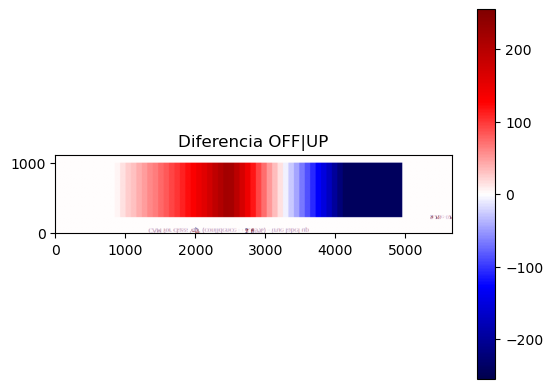

In [24]:
# CAM
cam_up = np.array(Image.open(f"{xai_path}/CAMs/0-55/item0/HiResCAM_layer4_1_conv2_class30.png").convert("L")).astype(np.float32)
cam_off = np.array(Image.open(f"{xai_path}/CAMs/0-55/item0/HiResCAM_layer4_1_conv2_class19.png").convert("L")).astype(np.float32)
delta = cam_up - cam_off
plt.imshow(delta, cmap="seismic", origin="lower")
plt.colorbar()
plt.title("Diferencia OFF|UP")
plt.show()

En este caso las diferencias en la evaluación del modelo parecen evidentes, lo que nos indica que el motivo principal es la poca confianza del modelo en la predicción. Es posible que, aún con unas buenas métricas cuantitativas, el checkpoint de la epoch 5 que hemos cargado sea demasiado temprano.

De cualquier manera, a juzgar por los mapas de calor que nos devuelve signal_grad_cam con ambos algoritmos para esta capa, el modelo le está dando mucha más importancia a la envolvente temporal de las muestras que a la dmensión frecuencial. A pesar de las buenas métricas del modelo, tenemos que valorar que parece que el modelo supedita la información frecuencial relevante a su posición en el eje temporal para su toma de decisiones. Como primera hipótesis, valoramos que la representación de los espectogramas pasados como entrada puede condicionar esto, y para validar si esto sucede en todas las capas de la CNN vamos a visualizar una muestra de algunas de ellas.

Para los estudios entre experimentos vamos a escoger unos samples de distintos hablantes que evaluaremos en todos.

In [25]:
tests_go = [path for path in X_test['path_normalized'] if 'go' in path][:5]
tests_go

['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_1.wav',
 '/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_2.wav',
 '/mnt/data/GSC/normalized-dataset/go/016e2c6d_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/go/016e2c6d_nohash_1.wav']

In [26]:
tests_off = [path for path in X_test['path_normalized'] if 'off' in path][:5]
tests_off

['/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_1.wav',
 '/mnt/data/GSC/normalized-dataset/off/035de8fe_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/off/035de8fe_nohash_1.wav',
 '/mnt/data/GSC/normalized-dataset/off/069ab0d5_nohash_0.wav']

In [27]:
tests_left = [path for path in X_test['path_normalized'] if 'left' in path][:5]
tests_left

['/mnt/data/GSC/normalized-dataset/left/012c8314_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/left/0227998e_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/left/035de8fe_nohash_0.wav',
 '/mnt/data/GSC/normalized-dataset/left/035de8fe_nohash_1.wav']

In [28]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [29]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

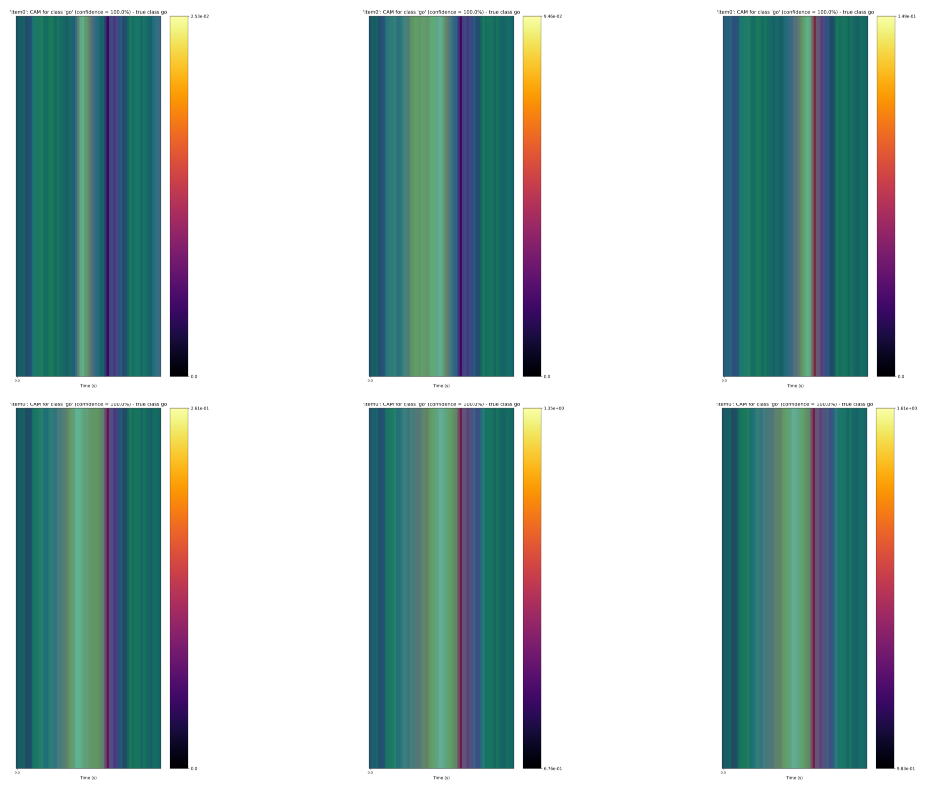

In [30]:
## Visualizamos
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

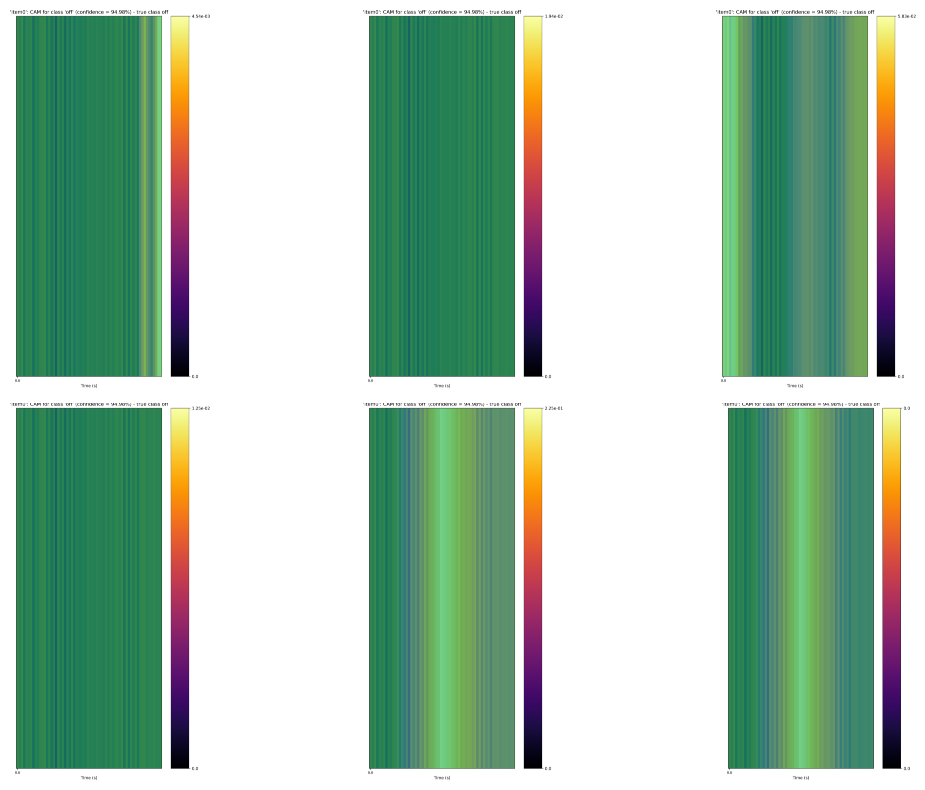

In [31]:
# "OFF"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*Grad*.png"))
show_image_grid(images_to_show)

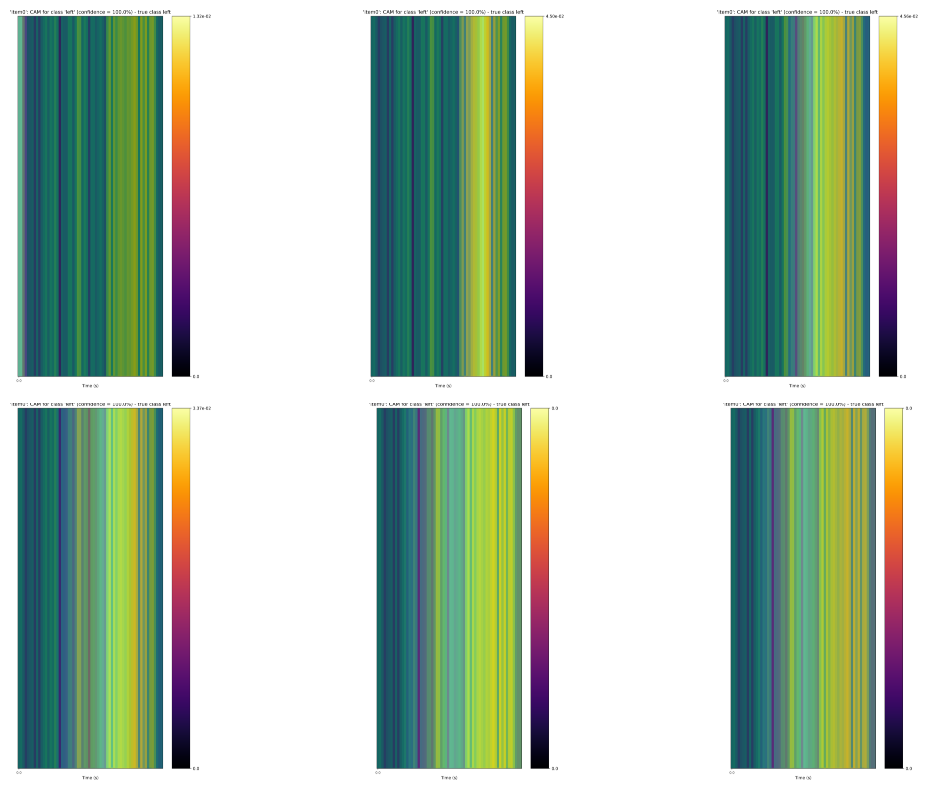

In [32]:
# "LEFT"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*Grad*.png"))
show_image_grid(images_to_show)

Vemos que, efectivamente, en todas las capas los gradientes se muestran como columnas a lo largo de la línea temporal, lo que apoya la intuición de que el modelo presenta un sesgo preferencial en este sentido. Como medida cuantitativa de los cambios que haremos en la pipeline tomaremos la confianza del modelo en las predicciones de los verdaderos positivos.

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [33]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)

53.308277821540834
